***Importing necessary libraries***

In [1]:
#pip install tensorflow==2.15.0

In [2]:
%reset -f
import numpy as np
import pandas as pd
import math

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
# Set pandas output display to have one digit for decimal places and limit it to
# printing 15 rows.
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 15

### Load the dataset with pandas


In [4]:
# Provide the names for the columns since the CSV file with the data does
# not have a header row.
feature_names = ['symboling', 'normalized-losses', 'make', 'fuel-type',
        'aspiration', 'num-doors', 'body-style', 'drive-wheels',
        'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
        'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
        'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg', 'price']


# Load in the data from a CSV file that is comma separated.
car_data = pd.read_csv('https://storage.googleapis.com/mledu-datasets/cars_data.csv',
                        sep=',', names=feature_names, header=None, encoding='latin-1')


# We'll then randomize the data, just to be sure not to get any pathological
# ordering effects that might harm the performance of Stochastic Gradient
# Descent.
car_data = car_data.reindex(np.random.permutation(car_data.index))

print("Data set loaded. Num examples: ", len(car_data))

Data set loaded. Num examples:  205


In [5]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 10 to 77
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-doors          205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  weight             205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-cylinders      205 non-null    object 
 16  engine-size        205 non-null

## Task 0: Use pandas to explore and prepare the data

- Use Pandas to inspect the data and manually curate a list of numeric_feature_names and categorical_feature_names.


Useful functions:
- `type()` called on any Python object describes the type of the object
- `dataframe[4:7]` pulls out rows 4, 5, 6 in a Pandas dataframe
- `dataframe[['mycol1', 'mycol2']]` pulls out the two requested columns into a new Pandas dataframe
- `dataframe['mycol1']` returns a Pandas series -- not a dataframe!
- `dataframe.describe()` prints out statistics for each dataframe column

In [6]:
car_data[4:7]

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
48,0,?,jaguar,gas,std,four,sedan,rwd,front,113.00,...,258,mpfi,3.63,4.17,8.10,176,4750,15,19,35550
4,2,164,audi,gas,std,four,sedan,4wd,front,99.40,...,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450
91,1,128,nissan,gas,std,two,sedan,fwd,front,94.50,...,97,2bbl,3.15,3.29,9.40,69,5200,31,37,6649


In [7]:
 LABEL = 'price'

numeric_feature_names = car_data[['symboling','normalized-losses','wheel-base','engine-size','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']]
categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))

# # The correct solution will pass these assert statements.
# assert len(numeric_feature_names) == 15
# assert len(categorical_feature_names) == 10

In [8]:
#@title Solution (to view code, from cell's menu, select Form -> Show Code)
numeric_feature_names = ['symboling', 'normalized-losses', 'wheel-base',
        'length', 'width', 'height', 'weight', 'engine-size', 'horsepower',
        'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke',
         'compression-ratio']

categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))

assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10

In [9]:
# Run to inspect numeric features.
car_data[numeric_feature_names]

,symboling,normalized-losses,wheel-base,length,width,height,weight,engine-size,horsepower,peak-rpm,city-mpg,highway-mpg,bore,stroke,compression-ratio
10,2,192,101.20,176.80,64.80,54.30,2395,108,101,5800,23,29,3.50,2.80,8.80
139,2,83,93.70,157.90,63.60,53.70,2120,108,73,4400,26,31,3.62,2.64,8.70
32,1,101,93.70,150.00,64.00,52.60,1837,79,60,5500,38,42,2.91,3.07,10.10
15,0,?,103.50,189.00,66.90,55.70,3230,209,182,5400,16,22,3.62,3.39,8.00
48,0,?,113.00,199.60,69.60,52.80,4066,258,176,4750,15,19,3.63,4.17,8.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,3,194,91.30,170.70,67.90,49.70,3139,181,200,5200,17,23,3.43,3.27,7.80
132,3,150,99.10,186.60,66.50,56.10,2658,121,110,5250,21,28,3.54,3.07,9.31
70,-1,93,115.60,202.60,71.70,56.30,3770,183,123,4350,22,25,3.58,3.64,21.50
76,2,161,93.70,157.30,64.40,50.80,1918,92,68,5500,37,41,2.97,3.23,9.40


In [10]:
# Run to inspect categorical features.
car_data[categorical_feature_names]

,fuel-type,drive-wheels,num-doors,engine-location,engine-type,make,aspiration,num-cylinders,body-style,fuel-system
10,gas,rwd,two,front,ohc,bmw,std,four,sedan,mpfi
139,gas,fwd,two,front,ohcf,subaru,std,four,hatchback,2bbl
32,gas,fwd,two,front,ohc,honda,std,four,hatchback,1bbl
15,gas,rwd,four,front,ohc,bmw,std,six,sedan,mpfi
48,gas,rwd,four,front,dohc,jaguar,std,six,sedan,mpfi
...,...,...,...,...,...,...,...,...,...,...
105,gas,rwd,two,front,ohcv,nissan,turbo,six,hatchback,mpfi
132,gas,fwd,two,front,ohc,saab,std,four,hatchback,mpfi
70,diesel,rwd,four,front,ohc,mercedes-benz,turbo,five,sedan,idi
76,gas,fwd,two,front,ohc,mitsubishi,std,four,hatchback,2bbl


In [11]:
# Coerce the numeric features to numbers. This is necessary because the model
# crashes because not all the values are numeric.
for feature_name in numeric_feature_names + [LABEL]:
  car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')

# Fill missing values with 0.
# Is this an OK thing to do? You may want to come back and revisit this decision later.
car_data.fillna(0, inplace=True)

## Task 1: Make your best model with numeric features. No normalization allowed.

Modify the model provided below to achieve the lowest eval loss. You may want to change various hyperparameters:
- learning rate
- choice of optimizer
- hidden layer dimensions -- make sure your choice here makes sense given the number of training examples
- batch size
- num training steps
- (anything else you can think of changing)

Do not use the `normalizer_fn` arg on `numeric_column`.

In [12]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Load and shuffle dataset
car_data = pd.read_csv('https://storage.googleapis.com/mledu-datasets/cars_data.csv', sep=',',
                       names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
                              'num-doors', 'body-style', 'drive-wheels', 'engine-location',
                              'wheel-base', 'length', 'width', 'height', 'weight', 'engine-type',
                              'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
                              'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
                              'highway-mpg', 'price'], header=None, encoding='latin-1')
car_data = car_data.reindex(np.random.permutation(car_data.index))

# Prepare numeric features and label
numeric_feature_names = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
                         'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm',
                         'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
LABEL = 'price'

# Ensure numeric features are coerced to numbers and fill NaNs with 0
for feature_name in numeric_feature_names + [LABEL]:
    car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')
car_data.fillna(0, inplace=True)

# Split data
x_df = car_data[numeric_feature_names]
y_series = car_data[LABEL]

# Input functions for training, evaluation, and prediction
batch_size = 16
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, num_epochs=None, shuffle=True)
eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, shuffle=False)
predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, batch_size=batch_size, shuffle=False)

# Feature columns and model configuration
model_feature_columns = [tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names]

# Adjusted DNNRegressor with optimized hyperparameters
est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[128, 64, 32],
    optimizer=tf.train.AdamOptimizer(learning_rate=0.005)
)

# Training and evaluation loop
num_training_steps = 20000
for _ in range(10):
    est.train(train_input_fn, steps=num_training_steps // 10)
    scores = est.evaluate(eval_input_fn)
    print('Evaluation scores:', scores)



Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
To construct input pipelines, use the `tf.data` module.
Instructions for updating:
To construct input pipelines, use the `tf.data` module.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.
Instructions for updating:


Evaluation scores: {'average_loss': 19668854.0, 'label/mean': 12949.43, 'loss': 310162720.0, 'prediction/mean': 11484.783, 'global_step': 2000}


Instructions for updating:
Use standard file utilities to get mtimes.


Evaluation scores: {'average_loss': 17686088.0, 'label/mean': 12949.43, 'loss': 278896000.0, 'prediction/mean': 11535.848, 'global_step': 4000}
Evaluation scores: {'average_loss': 15183886.0, 'label/mean': 12949.43, 'loss': 239438190.0, 'prediction/mean': 13573.695, 'global_step': 6000}
Evaluation scores: {'average_loss': 13125096.0, 'label/mean': 12949.43, 'loss': 206972670.0, 'prediction/mean': 13321.22, 'global_step': 8000}


Instructions for updating:
Use standard file APIs to delete files with this prefix.


Evaluation scores: {'average_loss': 10640922.0, 'label/mean': 12949.43, 'loss': 167799150.0, 'prediction/mean': 13393.444, 'global_step': 10000}
Evaluation scores: {'average_loss': 11637008.0, 'label/mean': 12949.43, 'loss': 183506670.0, 'prediction/mean': 14381.454, 'global_step': 12000}
Evaluation scores: {'average_loss': 7068606.0, 'label/mean': 12949.43, 'loss': 111466480.0, 'prediction/mean': 14070.153, 'global_step': 14000}
Evaluation scores: {'average_loss': 5238930.0, 'label/mean': 12949.43, 'loss': 82613896.0, 'prediction/mean': 13287.423, 'global_step': 16000}
Evaluation scores: {'average_loss': 5065936.0, 'label/mean': 12949.43, 'loss': 79885910.0, 'prediction/mean': 12692.353, 'global_step': 18000}


Evaluation scores: {'average_loss': 4439335.5, 'label/mean': 12949.43, 'loss': 70004904.0, 'prediction/mean': 12808.455, 'global_step': 20000}


In [13]:
# !pip show tensorflow
# tf.config.run_functions_eagerly(True)
#!pip install tensorflow-estimator

In [14]:

batch_size = 16

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

# Feature columns allow the model to parse the data, perform common
# preprocessing, and automatically generate an input layer for the tf.Estimator.
model_feature_columns = [
    tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)
  print('scores', scores)



['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
model_feature_columns [NumericColumn(key='symboling', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='normalized-losses', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='wheel-base', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='length', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='width', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='height', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='weight', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='engine-size', shape=(1,), default_value=None, dtype=t

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


scores {'average_loss': 33751264.0, 'label/mean': 12949.43, 'loss': 532231500.0, 'prediction/mean': 12997.392, 'global_step': 1000}


scores {'average_loss': 27047986.0, 'label/mean': 12949.43, 'loss': 426525920.0, 'prediction/mean': 13009.029, 'global_step': 2000}
scores {'average_loss': 25129492.0, 'label/mean': 12949.43, 'loss': 396272770.0, 'prediction/mean': 13179.6875, 'global_step': 3000}
scores {'average_loss': 24405802.0, 'label/mean': 12949.43, 'loss': 384860700.0, 'prediction/mean': 13144.363, 'global_step': 4000}
scores {'average_loss': 23970986.0, 'label/mean': 12949.43, 'loss': 378004000.0, 'prediction/mean': 13077.541, 'global_step': 5000}
scores {'average_loss': 23623530.0, 'label/mean': 12949.43, 'loss': 372524900.0, 'prediction/mean': 13045.171, 'global_step': 6000}
scores {'average_loss': 23334180.0, 'label/mean': 12949.43, 'loss': 367962080.0, 'prediction/mean': 13003.627, 'global_step': 7000}
scores {'average_loss': 23057118.0, 'label/mean': 12949.43, 'loss': 363593020.0, 'prediction/mean': 12924.939, 'global_step': 8000}
scores {'average_loss': 22783236.0, 'label/mean': 12949.43, 'loss': 3592741

### Visualize your model's predictions

After you have a trained model, it may be helpful to understand how your model's inference differs from the actual data.

This helper function `scatter_plot_inference` does that for you. Real data is in grey. Your model's predictions are in orange.


Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.


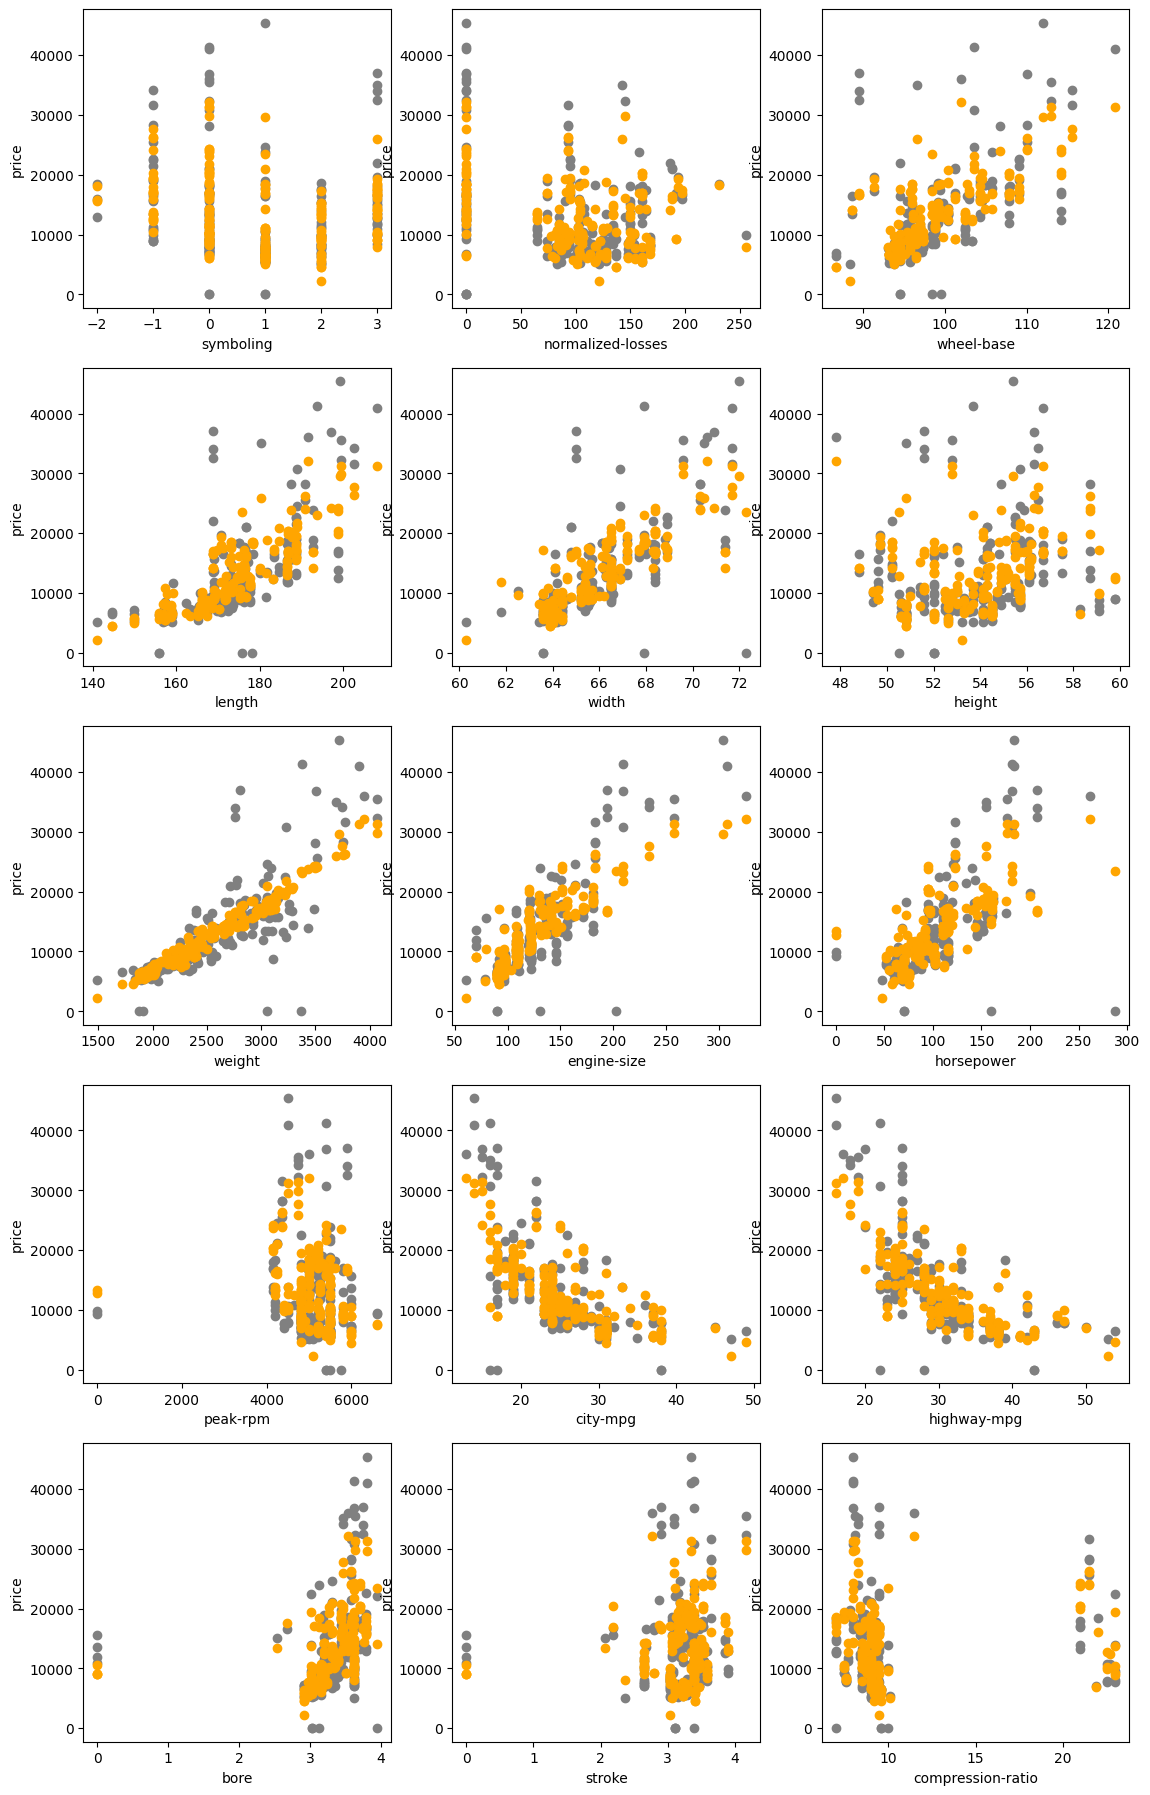

In [15]:
from matplotlib import pyplot as plt


def scatter_plot_inference_grid(est, x_df, feature_names):
  """Plots the predictions of the model against each feature.

  Args:
    est: The trained tf.Estimator.
    x_df: The pandas dataframe with the input data (used to create
      predict_input_fn).
    feature_names: An iterable of string feature names to plot.
  """
  def scatter_plot_inference(axis,
                             x_axis_feature_name,
                             y_axis_feature_name,
                             predictions):
    """Generate one subplot."""
    # Plot the real data in grey.
    y_axis_feature_name = 'price'
    axis.set_ylabel(y_axis_feature_name)
    axis.set_xlabel(x_axis_feature_name)
    axis.scatter(car_data[x_axis_feature_name],
                 car_data[y_axis_feature_name],
                 c='grey')

    # Plot the predicted data in orange.
    axis.scatter(car_data[x_axis_feature_name], predictions, c='orange')

  predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

  predictions = [
    x['predictions'][0]
    for x in est.predict(predict_input_fn)
  ]

  num_cols = 3
  num_rows = int(math.ceil(len(feature_names)/float(num_cols)))
  f, axarr = plt.subplots(num_rows, num_cols)
  size = 4.5
  f.set_size_inches(num_cols*size, num_rows*size)

  for i, feature_name in enumerate(numeric_feature_names):
    axis = axarr[int(i/num_cols), i%num_cols]
    scatter_plot_inference(axis, feature_name, 'price', predictions)
  plt.show()

scatter_plot_inference_grid(est, x_df, numeric_feature_names)

## Task 2: Take your best numeric model from earlier. Add normalization.

### Add normalization to your best numeric model from earlier

- You decide what type of normalization to add, and for which features
- You will need to use the `normalizer_fn` arg on [`numeric_column`](https://g3doc.corp.google.com/learning/brain/public/g3doc/api_docs/python/tf/feature_column/numeric_column.md?cl=head)
    - An example of a silly normalizer_fn that shifts inputs down by 1, and then negates the value:
    
         normalizer_fn = lambda x: tf.neg(tf.subtract(x, 1))

- You may find these pandas functions helpful:
    - dataframe.mean()['your_feature_name']
    - dataframe.std()['your_feature_name']
- You will need to retune the hyperparameters from earlier.


**Does normalization improve model quality on this dataset? Why or why not?**

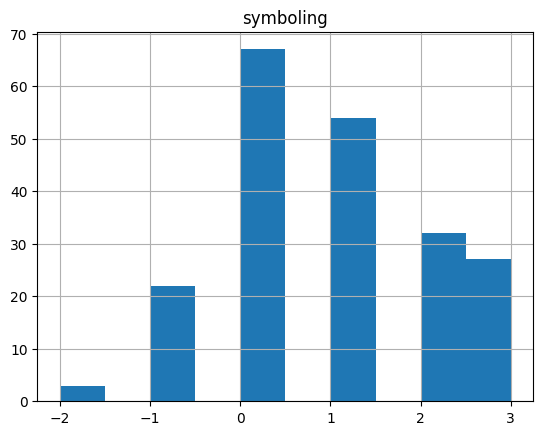

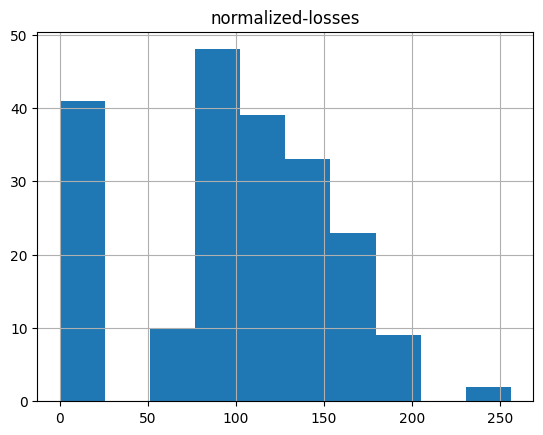

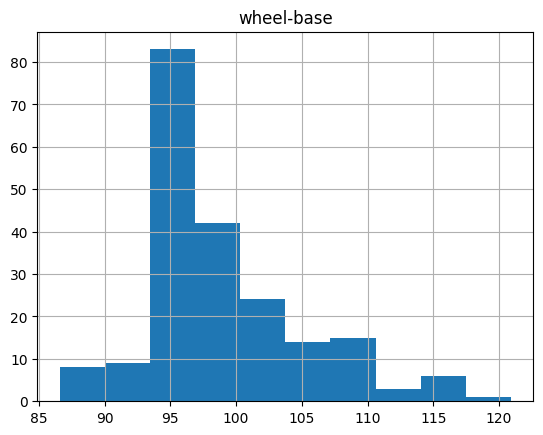

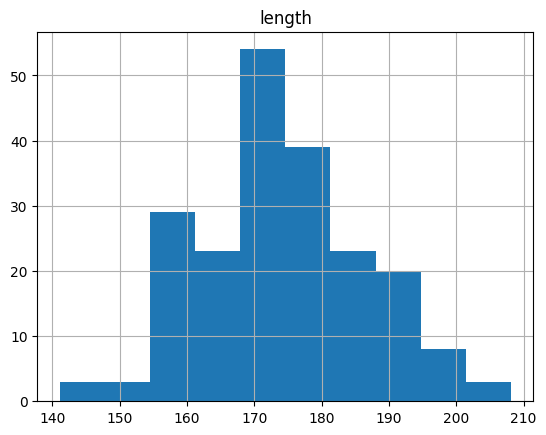

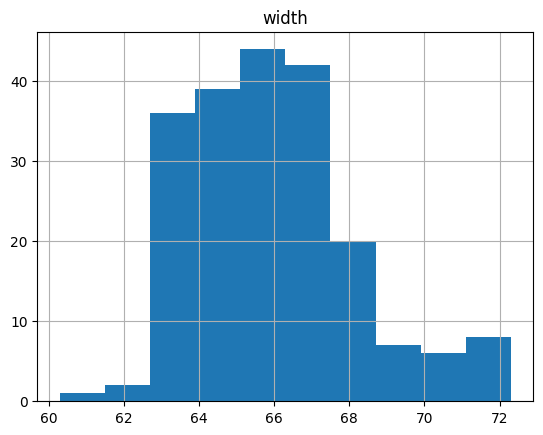

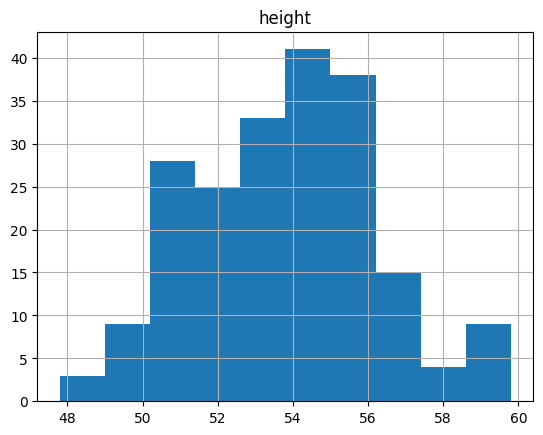

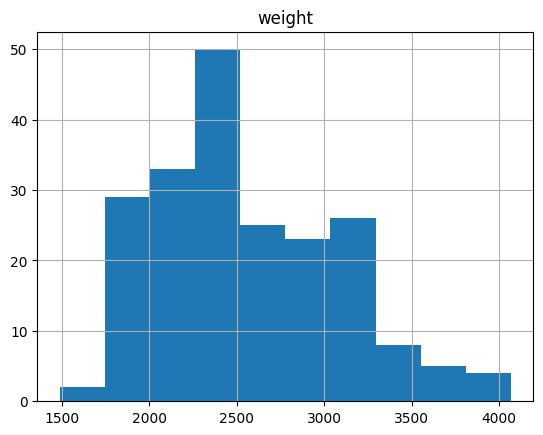

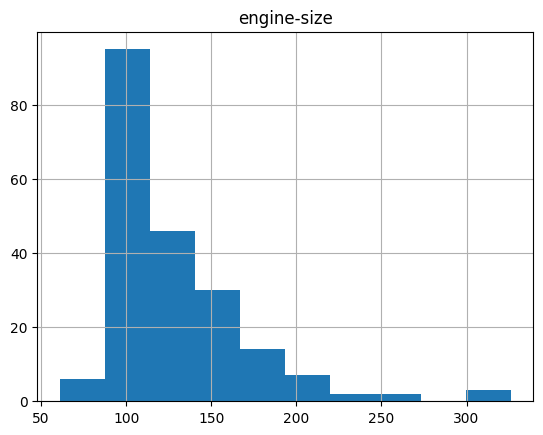

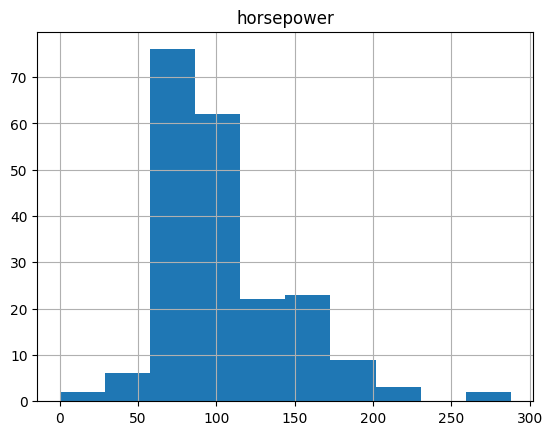

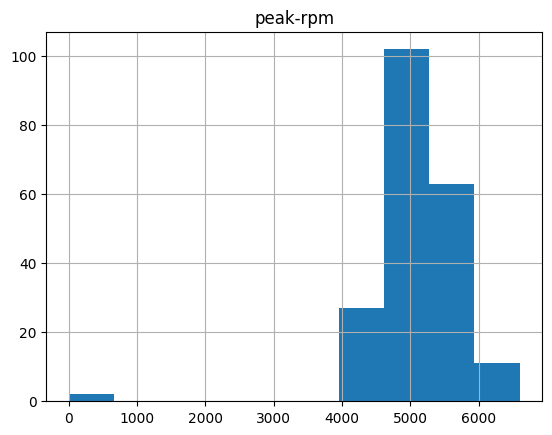

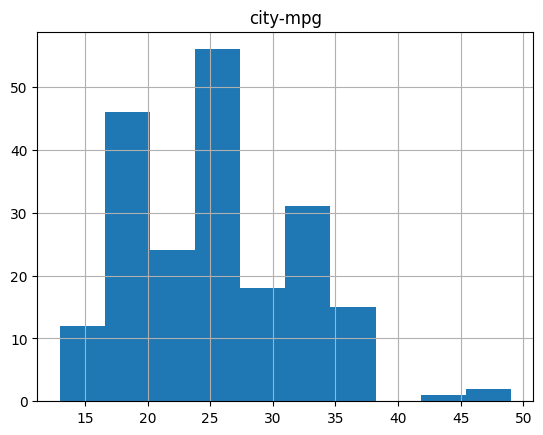

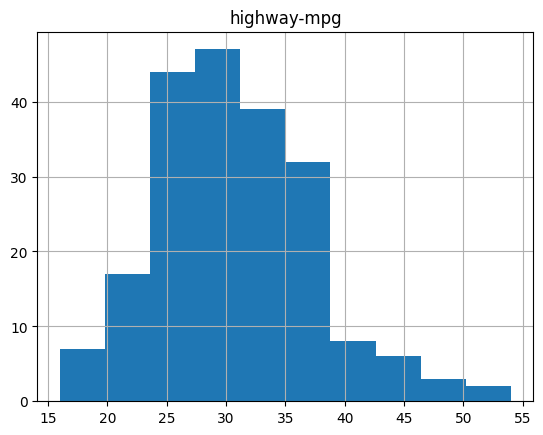

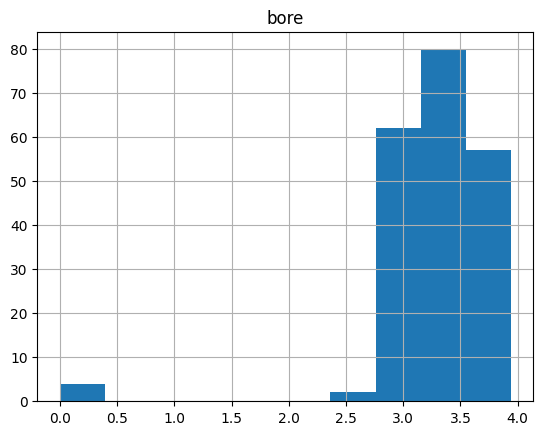

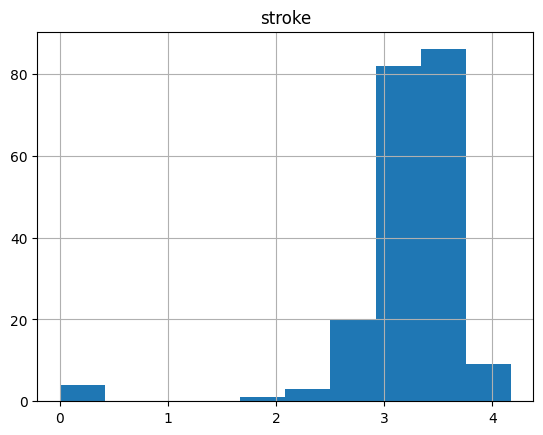

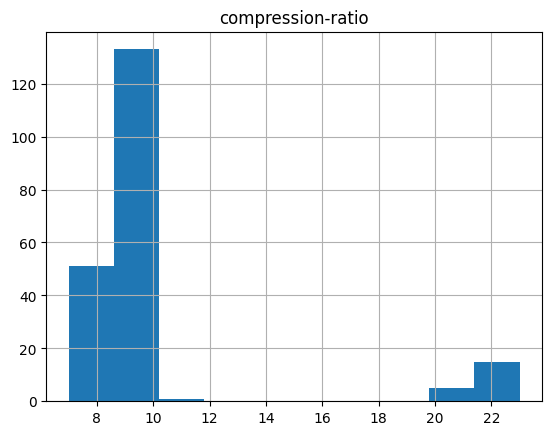

In [16]:
# This 1D visualization of each numeric feature might inform your normalization
# decisions.
for feature_name in numeric_feature_names:
  car_data.hist(column=feature_name)

###Train your model with numeric features + normalization

['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
model_feature_columns [NumericColumn(key='symboling', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x7c2971ed9120>), NumericColumn(key='normalized-losses', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x7c2971ed9900>), NumericColumn(key='wheel-base', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x7c2971ed93f0>), NumericColumn(key='length', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x7c2971ed9360>), NumericColumn(key='width', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x7c2971ed92d0>), NumericColumn(key='height', shape=(1,), default_va

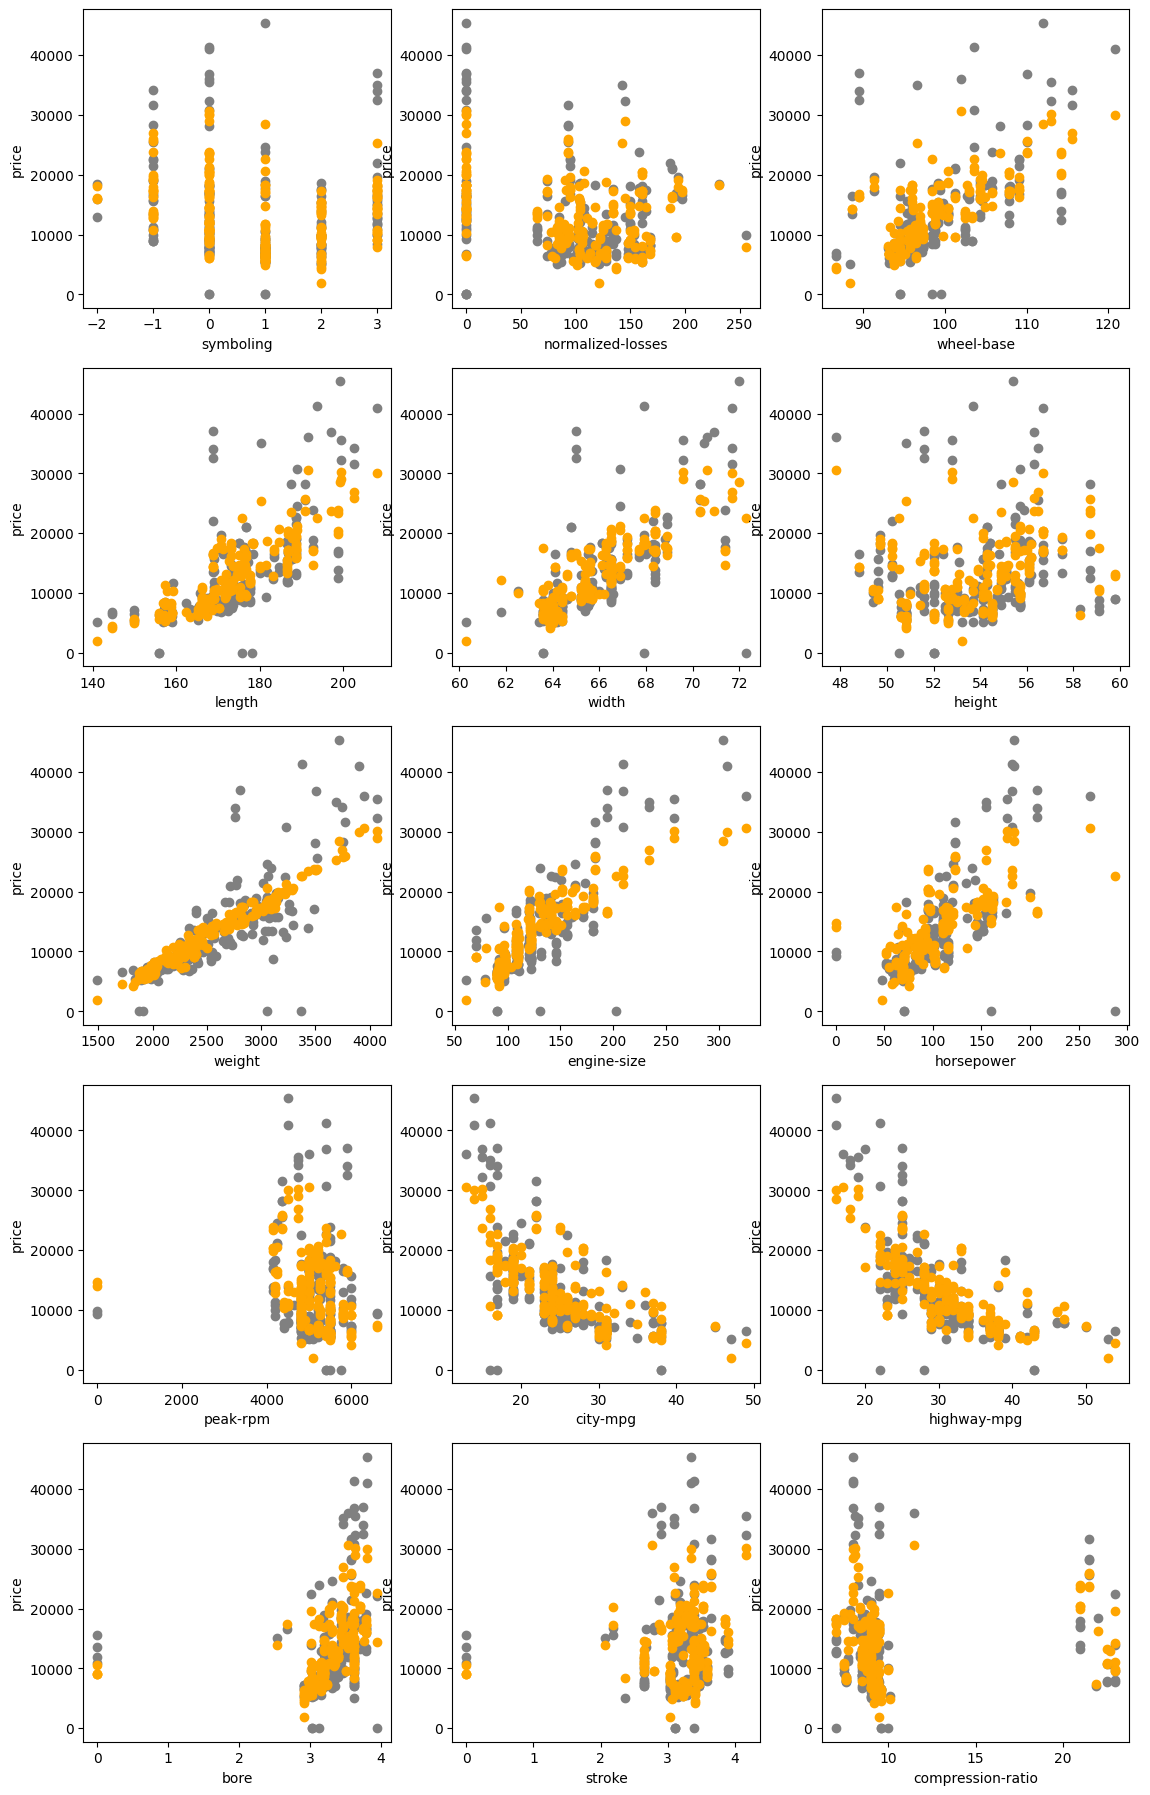

In [18]:

batch_size = 16

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

# Epsilon prevents divide by zero.
epsilon = 0.000001
model_feature_columns = [
    tf.feature_column.numeric_column(feature_name,
                                     normalizer_fn=lambda val: (val - x_df.mean()[feature_name]) / (epsilon + x_df.std()[feature_name]))
    for feature_name in numeric_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 20000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)
  print('scores', scores)

scatter_plot_inference_grid(est, x_df, numeric_feature_names)

## Task 3: Make your best model using only categorical features

- Look at the possible feature columns for categorical features. They begin with `categorical_column_with_` in go/tf-ops.
- You may find `dataframe[categorical_feature_names].unique()` helpful.


In [20]:

batch_size = 16

x_df = car_data[categorical_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

model_feature_columns = [
    tf.feature_column.indicator_column(
        tf.feature_column.categorical_column_with_vocabulary_list(
            feature_name, vocabulary_list=car_data[feature_name].unique()))
    for feature_name in categorical_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

# TRAIN
num_print_statements = 10
num_training_steps = 20000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)
  print('scores', scores)



Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


model_feature_columns [IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='fuel-type', vocabulary_list=('gas', 'diesel'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='drive-wheels', vocabulary_list=('fwd', 'rwd', '4wd'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='num-doors', vocabulary_list=('four', 'two', '?'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='engine-location', vocabulary_list=('front', 'rear'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='engine-type', vocabulary_list=('ohc', 'ohcf', 'dohc', 'l', 'rotor', 'ohcv', 'dohcv'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyLi

## Task 4: Using all the features, make the best model that you can make

With all the features combined, your model should perform better than your earlier models using numerical and categorical models alone. Tune your model until that is the case.

In [22]:
#@title Possible solution
# This is a first pass at a model that uses all the features.
# Do you have any improvements?

import tensorflow as tf
import pandas as pd

# Define batch size and epsilon to avoid division by zero
batch_size = 16
epsilon = 1e-6

# Assuming car_data, numeric_feature_names, and categorical_feature_names are already defined

# Separate numeric and categorical data, ensuring numeric columns are of float32 dtype
x_df_numeric = car_data[numeric_feature_names].astype('float32')
x_df_categorical = car_data[categorical_feature_names]
y_series = car_data['price']

# Normalize only the numeric features with explicit casting to float32
model_numeric_columns = [
    tf.feature_column.numeric_column(
        feature_name,
        normalizer_fn=lambda val, fn=feature_name: tf.cast(
            (val - x_df_numeric[fn].mean()) / (epsilon + x_df_numeric[fn].std()), tf.float32
        )
    ) for feature_name in numeric_feature_names
]

# Categorical feature columns
model_categorical_columns = [
    tf.feature_column.indicator_column(
        tf.feature_column.categorical_column_with_vocabulary_list(
            feature_name, vocabulary_list=car_data[feature_name].unique()
        )
    ) for feature_name in categorical_feature_names
]

# Combine numeric and categorical columns
model_feature_columns = model_numeric_columns + model_categorical_columns

# Define input functions for training and evaluation
train_input_fn = tf.compat.v1.estimator.inputs.pandas_input_fn(
    x=pd.concat([x_df_numeric, x_df_categorical], axis=1),
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True
)

eval_input_fn = tf.compat.v1.estimator.inputs.pandas_input_fn(
    x=pd.concat([x_df_numeric, x_df_categorical], axis=1),
    y=y_series,
    batch_size=batch_size,
    shuffle=False
)

# Training and evaluation loop
num_print_statements = 10
num_training_steps = 10000

for _ in range(num_print_statements):
    # Reinitialize the DNNRegressor with a fresh optimizer instance in each loop
    est = tf.estimator.DNNRegressor(
        feature_columns=model_feature_columns,
        hidden_units=[64],
        optimizer=tf.keras.optimizers.legacy.Adagrad(learning_rate=0.01)
    )

    # Train and evaluate
    est.train(train_input_fn, steps=num_training_steps // num_print_statements)
    scores = est.evaluate(eval_input_fn)
    print('scores:', scores)


Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.


scores: {'average_loss': 222886740.0, 'label/mean': 12949.43, 'loss': 222101760.0, 'prediction/mean': 307.19592, 'global_step': 1000}


scores: {'average_loss': 223304600.0, 'label/mean': 12949.43, 'loss': 222518900.0, 'prediction/mean': 291.22556, 'global_step': 1000}


scores: {'average_loss': 221564690.0, 'label/mean': 12949.43, 'loss': 220784560.0, 'prediction/mean': 347.85767, 'global_step': 1000}


scores: {'average_loss': 222667230.0, 'label/mean': 12949.43, 'loss': 221882700.0, 'prediction/mean': 315.31244, 'global_step': 1000}


scores: {'average_loss': 221579730.0, 'label/mean': 12949.43, 'loss': 220799260.0, 'prediction/mean': 347.45016, 'global_step': 1000}


scores: {'average_loss': 221550930.0, 'label/mean': 12949.43, 'loss': 220771150.0, 'prediction/mean': 347.23932, 'global_step': 1000}


scores: {'average_loss': 223217230.0, 'label/mean': 12949.43, 'loss': 222433040.0, 'prediction/mean': 292.59918, 'global_step': 1000}


scores: {'average_loss': 222332670.0, 'label/mean': 12949.43, 'loss': 221550320.0, 'prediction/mean': 324.57123, 'global_step': 1000}


scores: {'average_loss': 222269740.0, 'label/mean': 12949.43, 'loss': 221486880.0, 'prediction/mean': 326.1779, 'global_step': 1000}
scores: {'average_loss': 223543360.0, 'label/mean': 12949.43, 'loss': 222756030.0, 'prediction/mean': 287.945, 'global_step': 1000}


**CREATING CUSTOM MODEL - USING REGRESSOR FUCNTIONS**

**Task 1 numerical feature names for using with Linear regressor model**

In [23]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Load and shuffle dataset
car_data = pd.read_csv('https://storage.googleapis.com/mledu-datasets/cars_data.csv', sep=',',
                       names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
                              'num-doors', 'body-style', 'drive-wheels', 'engine-location',
                              'wheel-base', 'length', 'width', 'height', 'weight', 'engine-type',
                              'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
                              'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
                              'highway-mpg', 'price'], header=None, encoding='latin-1')
car_data = car_data.reindex(np.random.permutation(car_data.index))

# Prepare numeric features and label
numeric_feature_names = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
                         'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm',
                         'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
LABEL = 'price'

# Ensure numeric features are coerced to numbers and fill NaNs with 0
for feature_name in numeric_feature_names + [LABEL]:
    car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')
car_data.fillna(0, inplace=True)


# Split data
x_df = car_data[numeric_feature_names]
y_series = car_data[LABEL]


# Input functions for training, evaluation, and prediction
batch_size = 16
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, num_epochs=None, shuffle=True)
eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, shuffle=False)
predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, batch_size=batch_size, shuffle=False)


# Feature columns
model_feature_columns = [tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names]

# Linear Regression model
est = tf.estimator.LinearRegressor(
    feature_columns=model_feature_columns
)


# Training and evaluation loop
num_training_steps = 20000
for _ in range(10):
    est.train(train_input_fn, steps=num_training_steps // 10)
    scores = est.evaluate(eval_input_fn)
    print('Evaluation scores:', scores)


Instructions for updating:
Use tf.keras instead.
Instructions for updating:
Use tf.keras instead.


Evaluation scores: {'average_loss': 32382606.0, 'label/mean': 12949.43, 'loss': 510648800.0, 'prediction/mean': 13138.32, 'global_step': 2000}
Evaluation scores: {'average_loss': 27915120.0, 'label/mean': 12949.43, 'loss': 440199970.0, 'prediction/mean': 13114.801, 'global_step': 4000}
Evaluation scores: {'average_loss': 26260642.0, 'label/mean': 12949.43, 'loss': 414110140.0, 'prediction/mean': 13074.002, 'global_step': 6000}
Evaluation scores: {'average_loss': 25430426.0, 'label/mean': 12949.43, 'loss': 401018240.0, 'prediction/mean': 13149.098, 'global_step': 8000}
Evaluation scores: {'average_loss': 24925366.0, 'label/mean': 12949.43, 'loss': 393053860.0, 'prediction/mean': 13139.32, 'global_step': 10000}
Evaluation scores: {'average_loss': 24576556.0, 'label/mean': 12949.43, 'loss': 387553400.0, 'prediction/mean': 13051.2, 'global_step': 12000}
Evaluation scores: {'average_loss': 24289822.0, 'label/mean': 12949.43, 'loss': 383031800.0, 'prediction/mean': 13132.808, 'global_step': 

**Task 3 : Categorical feature names for usign with Linear regressor model**

In [24]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Load and shuffle dataset
car_data = pd.read_csv('https://storage.googleapis.com/mledu-datasets/cars_data.csv', sep=',',
                       names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
                              'num-doors', 'body-style', 'drive-wheels', 'engine-location',
                              'wheel-base', 'length', 'width', 'height', 'weight', 'engine-type',
                              'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
                              'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
                              'highway-mpg', 'price'], header=None, encoding='latin-1')
car_data = car_data.reindex(np.random.permutation(car_data.index))

# Prepare numeric features and label
numeric_feature_names = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
                         'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm',
                         'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
LABEL = 'price'

# Ensure numeric features are coerced to numbers and fill NaNs with 0
for feature_name in numeric_feature_names + [LABEL]:
    car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')
car_data.fillna(0, inplace=True)


# Split data
x_df = car_data[numeric_feature_names]
y_series = car_data[LABEL]


# Input functions for training, evaluation, and prediction
batch_size = 16
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, num_epochs=None, shuffle=True)
eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, shuffle=False)
predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, batch_size=batch_size, shuffle=False)


# Feature columns
model_feature_columns = [tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names]

# Linear Regression model
est = tf.estimator.LinearRegressor(
    feature_columns=model_feature_columns
)


# Training and evaluation loop
num_training_steps = 20000
for _ in range(10):
    est.train(train_input_fn, steps=num_training_steps // 10)
    scores = est.evaluate(eval_input_fn)
    print('Evaluation scores:', scores)


Evaluation scores: {'average_loss': 32587954.0, 'label/mean': 12949.43, 'loss': 513886940.0, 'prediction/mean': 13090.74, 'global_step': 2000}
Evaluation scores: {'average_loss': 28064324.0, 'label/mean': 12949.43, 'loss': 442552800.0, 'prediction/mean': 13102.133, 'global_step': 4000}
Evaluation scores: {'average_loss': 26355548.0, 'label/mean': 12949.43, 'loss': 415606720.0, 'prediction/mean': 13176.706, 'global_step': 6000}
Evaluation scores: {'average_loss': 25506840.0, 'label/mean': 12949.43, 'loss': 402223260.0, 'prediction/mean': 13231.398, 'global_step': 8000}
Evaluation scores: {'average_loss': 24984162.0, 'label/mean': 12949.43, 'loss': 393981000.0, 'prediction/mean': 13186.588, 'global_step': 10000}
Evaluation scores: {'average_loss': 24618944.0, 'label/mean': 12949.43, 'loss': 388221800.0, 'prediction/mean': 13135.278, 'global_step': 12000}
Evaluation scores: {'average_loss': 24336648.0, 'label/mean': 12949.43, 'loss': 383770240.0, 'prediction/mean': 13118.839, 'global_step

**Task 4: Using all the features, with Linear regressor model**

In [25]:
import numpy as np
import pandas as pd
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# Load and shuffle dataset
car_data = pd.read_csv('https://storage.googleapis.com/mledu-datasets/cars_data.csv', sep=',',
                       names=['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
                              'num-doors', 'body-style', 'drive-wheels', 'engine-location',
                              'wheel-base', 'length', 'width', 'height', 'weight', 'engine-type',
                              'num-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
                              'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
                              'highway-mpg', 'price'], header=None, encoding='latin-1')
car_data = car_data.reindex(np.random.permutation(car_data.index))

# Prepare numeric features and label
numeric_feature_names = ['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
                         'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm',
                         'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
LABEL = 'price'

# Ensure numeric features are coerced to numbers and fill NaNs with 0
for feature_name in numeric_feature_names + [LABEL]:
    car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')
car_data.fillna(0, inplace=True)

# Split data
x_df = car_data[numeric_feature_names]
y_series = car_data[LABEL]

# Input functions for training, evaluation, and prediction
batch_size = 16
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, num_epochs=None, shuffle=True)
eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, y=y_series, batch_size=batch_size, shuffle=False)
predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df, batch_size=batch_size, shuffle=False)

# Feature columns
model_feature_columns = [tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names]

# Linear Regression model
est = tf.estimator.LinearRegressor(
    feature_columns=model_feature_columns
)

# Training and evaluation loop
num_training_steps = 20000
for _ in range(10):
    est.train(train_input_fn, steps=num_training_steps // 10)
    scores = est.evaluate(eval_input_fn)
    print('Evaluation scores:', scores)


Evaluation scores: {'average_loss': 32030300.0, 'label/mean': 12949.43, 'loss': 505093200.0, 'prediction/mean': 13043.908, 'global_step': 2000}
Evaluation scores: {'average_loss': 27773510.0, 'label/mean': 12949.43, 'loss': 437966880.0, 'prediction/mean': 13120.549, 'global_step': 4000}
Evaluation scores: {'average_loss': 26182890.0, 'label/mean': 12949.43, 'loss': 412884030.0, 'prediction/mean': 13194.961, 'global_step': 6000}
Evaluation scores: {'average_loss': 25381404.0, 'label/mean': 12949.43, 'loss': 400245220.0, 'prediction/mean': 13141.433, 'global_step': 8000}
Evaluation scores: {'average_loss': 24891334.0, 'label/mean': 12949.43, 'loss': 392517200.0, 'prediction/mean': 13139.946, 'global_step': 10000}
Evaluation scores: {'average_loss': 24549564.0, 'label/mean': 12949.43, 'loss': 387127740.0, 'prediction/mean': 13070.546, 'global_step': 12000}
Evaluation scores: {'average_loss': 24272556.0, 'label/mean': 12949.43, 'loss': 382759550.0, 'prediction/mean': 13115.872, 'global_ste